In [1]:
# HealthGuard AI - Stroke Model Training
# Author: HealthGuard AI Team
# Date: 2026
# Version: 2.0

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report,
                             roc_curve, auc)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     StratifiedKFold)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8')

print("=" * 50)
print("  HealthGuard AI - Stroke Model Training v2.0")
print("=" * 50)
print("Libraries Loaded Successfully!")

  HealthGuard AI - Stroke Model Training v2.0
Libraries Loaded Successfully!


In [2]:
# Load Data

X_train = pd.read_csv("E:/HealthGuard_AI/data/processed/stroke_X_train.csv")
X_test = pd.read_csv("E:/HealthGuard_AI/data/processed/stroke_X_test.csv")
y_train = pd.read_csv("E:/HealthGuard_AI/data/processed/stroke_y_train.csv").values.ravel()
y_test = pd.read_csv("E:/HealthGuard_AI/data/processed/stroke_y_test.csv").values.ravel()

print("Data Loaded Successfully!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"\nTraining Class Distribution:")
print(f"No Stroke: {(y_train==0).sum()}")
print(f"Stroke: {(y_train==1).sum()}")

Data Loaded Successfully!
X_train Shape: (6750, 10)
X_test Shape: (877, 10)

Training Class Distribution:
No Stroke: 3375
Stroke: 3375


STEP 1: CROSS VALIDATION (5-FOLD)
Cross Validation Results:
----------------------------------------

Logistic Regression:
  Mean F1: 0.7989
  Std F1:  0.0089
  Scores:  [0.798  0.8    0.8118 0.7839 0.8006]

Random Forest:
  Mean F1: 0.9671
  Std F1:  0.0038
  Scores:  [0.9729 0.9621 0.9692 0.9674 0.9638]

XGBoost:
  Mean F1: 0.9665
  Std F1:  0.0050
  Scores:  [0.9727 0.9585 0.9704 0.9636 0.9674]

SVM:
  Mean F1: 0.8767
  Std F1:  0.0037
  Scores:  [0.8717 0.8763 0.8741 0.8816 0.88  ]

Neural Network:
  Mean F1: 0.9639
  Std F1:  0.0069
  Scores:  [0.9717 0.9516 0.9641 0.9633 0.969 ]


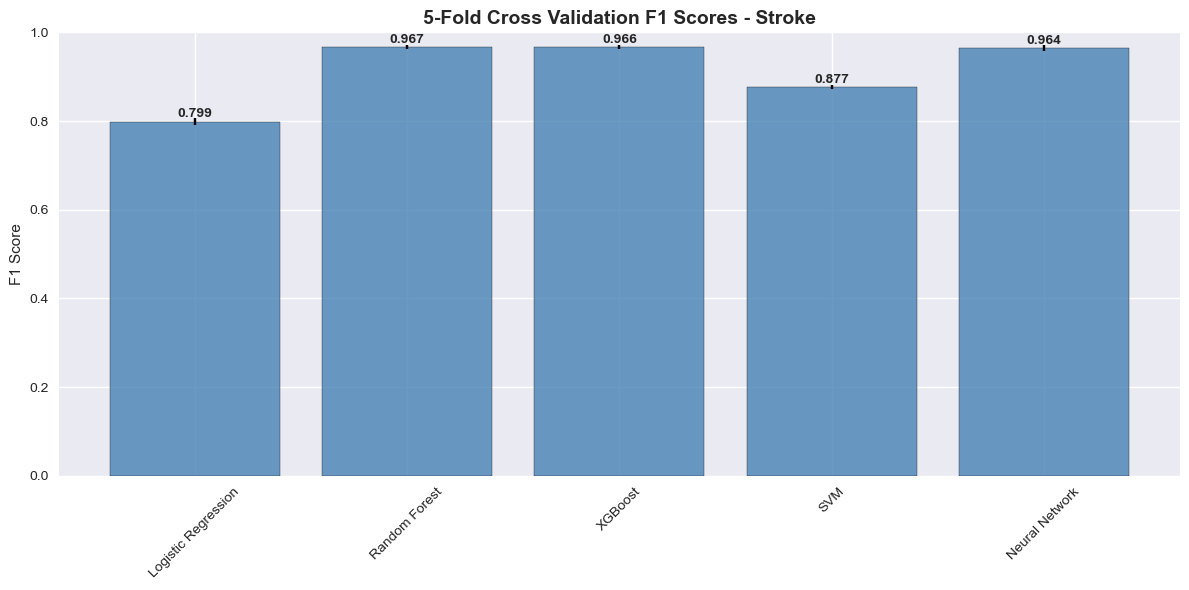

In [3]:
# Step 1: Cross Validation

print("=" * 50)
print("STEP 1: CROSS VALIDATION (5-FOLD)")
print("=" * 50)

cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=42,
                                              max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                           random_state=42),
    'XGBoost': XGBClassifier(random_state=42,
                              eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),
                                    max_iter=500,
                                    random_state=42)
}

cv_results = {}

print("Cross Validation Results:")
print("-" * 40)

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1')
    cv_results[name] = {
        'Mean F1': cv_scores.mean(),
        'Std F1': cv_scores.std(),
        'All Scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"  Mean F1: {cv_scores.mean():.4f}")
    print(f"  Std F1:  {cv_scores.std():.4f}")
    print(f"  Scores:  {cv_scores.round(4)}")

plt.figure(figsize=(12, 6))
names = list(cv_results.keys())
means = [cv_results[n]['Mean F1'] for n in names]
stds = [cv_results[n]['Std F1'] for n in names]

bars = plt.bar(names, means, yerr=stds,
               color='steelblue', edgecolor='black',
               capsize=5, alpha=0.8)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontweight='bold')

plt.title('5-Fold Cross Validation F1 Scores - Stroke',
          fontweight='bold', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Step 2: Hyperparameter Tuning
# Added class_weight/scale_pos_weight for imbalanced stroke data

print("=" * 50)
print("STEP 2: HYPERPARAMETER TUNING")
print("=" * 50)

# Calculate imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

print("\nTuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF F1: {rf_grid.best_score_:.4f}")

print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [1, scale_pos_weight]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB F1: {xgb_grid.best_score_:.4f}")

print("\nHyperparameter Tuning Complete!")

STEP 2: HYPERPARAMETER TUNING
Class imbalance ratio (scale_pos_weight): 1.00

Tuning Random Forest...
Best RF Params: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF F1: 0.9670

Tuning XGBoost...
Best XGB Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 1.0}
Best XGB F1: 0.9622

Hyperparameter Tuning Complete!


In [5]:
# Step 3: Train Final Models with Class Weighting

print("=" * 50)
print("STEP 3: TRAIN FINAL MODELS")
print("=" * 50)

final_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000,
        class_weight='balanced'),
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'SVM': SVC(probability=True, random_state=42,
               class_weight='balanced'),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500, random_state=42)
}

results = {}

for name, model in final_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC ROC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Model': model
    }

    print(f"Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"Precision: {results[name]['Precision']:.4f}")
    print(f"Recall:    {results[name]['Recall']:.4f}")
    print(f"F1 Score:  {results[name]['F1 Score']:.4f}")

print("\nAll Models Trained (with class balancing)!")

STEP 3: TRAIN FINAL MODELS

Training Logistic Regression...
Accuracy:  0.7480
Precision: 0.1116
Recall:    0.8182
F1 Score:  0.1964

Training Random Forest...
Accuracy:  0.9327
Precision: 0.0938
Recall:    0.0909
F1 Score:  0.0923

Training XGBoost...
Accuracy:  0.9555
Precision: 0.3333
Recall:    0.1818
F1 Score:  0.2353

Training SVM...
Accuracy:  0.8062
Precision: 0.1215
Recall:    0.6667
F1 Score:  0.2056

Training Neural Network...
Accuracy:  0.9236
Precision: 0.1136
Recall:    0.1515
F1 Score:  0.1299

All Models Trained (with class balancing)!


                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.7480     0.1116  0.8182    0.1964   0.8639
Random Forest          0.9327     0.0938  0.0909    0.0923   0.8204
XGBoost                0.9555     0.3333  0.1818    0.2353   0.8267
SVM                    0.8062     0.1215  0.6667    0.2056   0.8142
Neural Network         0.9236     0.1136  0.1515    0.1299   0.7722


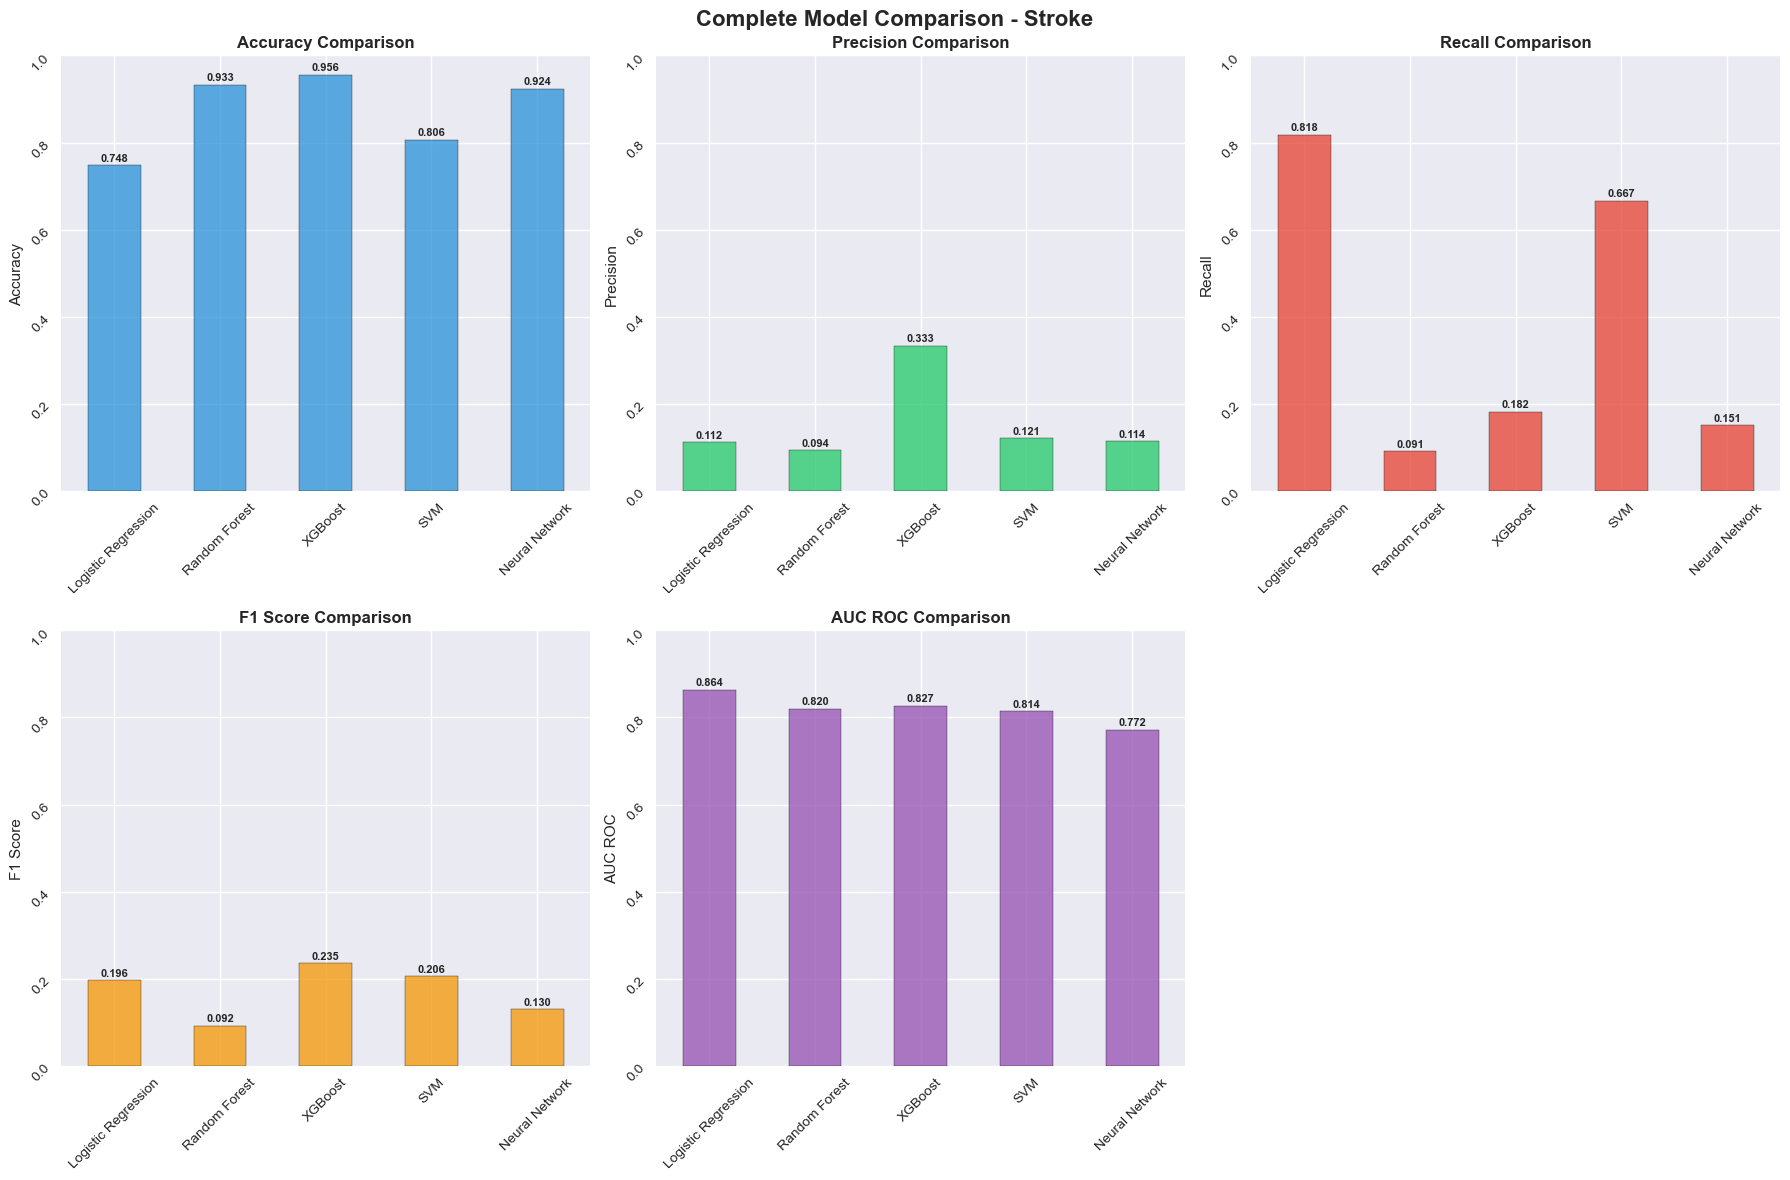

In [6]:
# Step 4: Model Comparison

results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['Accuracy'],
        'Precision': results[name]['Precision'],
        'Recall': results[name]['Recall'],
        'F1 Score': results[name]['F1 Score'],
        'AUC ROC': results[name]['AUC ROC']
    }
    for name in results
}).T.round(4)

print(results_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall',
           'F1 Score', 'AUC ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c',
          '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar',
                            ax=axes[i],
                            color=colors[i],
                            edgecolor='black',
                            alpha=0.8)
    axes[i].set_title(f'{metric} Comparison',
                      fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(rotation=45)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=8,
                    fontweight='bold')

axes[5].set_visible(False)

plt.suptitle('Complete Model Comparison - Stroke',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

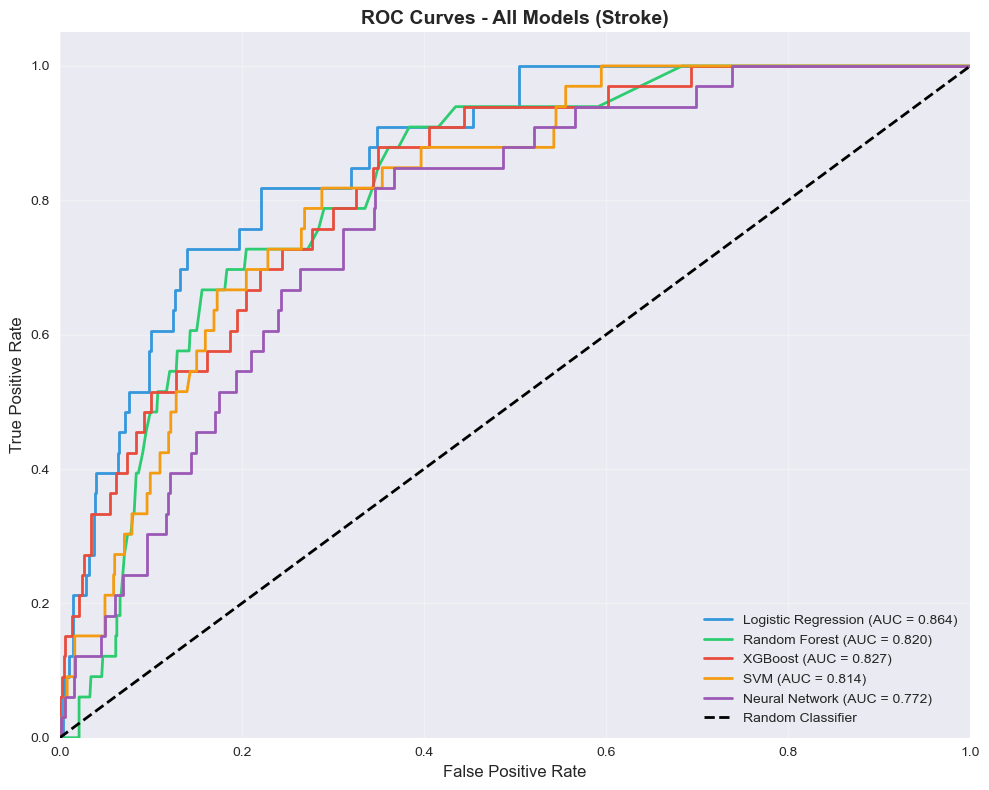

In [7]:
# Step 5: ROC Curve

plt.figure(figsize=(10, 8))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c',
              '#f39c12', '#9b59b6']

for (name, result), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2,
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Stroke)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best Model: XGBoost
Accuracy:  0.9555
Precision: 0.3333
Recall:    0.1818
F1 Score:  0.2353
AUC ROC:   0.8267


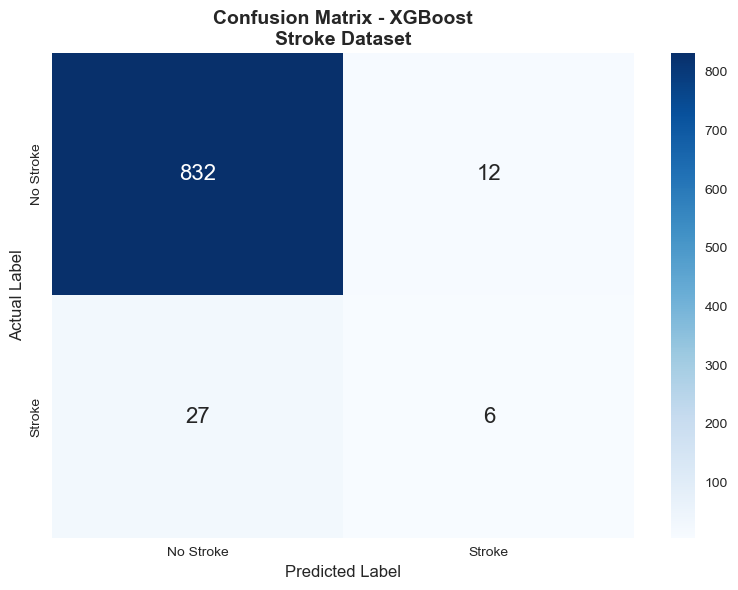

              precision    recall  f1-score   support

   No Stroke       0.97      0.99      0.98       844
      Stroke       0.33      0.18      0.24        33

    accuracy                           0.96       877
   macro avg       0.65      0.58      0.61       877
weighted avg       0.94      0.96      0.95       877



In [8]:
# Step 6: Best Model & Confusion Matrix

best_model_name = results_df['F1 Score'].idxmax()
best_model = results[best_model_name]['Model']
y_pred_best = results[best_model_name]['y_pred']

print(f"Best Model: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}\n'
          f'Stroke Dataset',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best,
      target_names=['No Stroke', 'Stroke']))

In [9]:
# Step: Threshold Optimization
# Find optimal decision threshold using Precision-Recall curve
# on TRAINING data only (avoids test set leakage)

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

print("=" * 50)
print("THRESHOLD OPTIMIZATION")
print("=" * 50)

# Get cross-validated probabilities on TRAINING data (not test!)
cv_probs = cross_val_predict(
    best_model, X_train, y_train, cv=5,
    method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_train, cv_probs)

# F1 score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[best_idx]

print(f"Default threshold: 0.50")
print(f"Optimal threshold (from training CV): {optimal_threshold:.4f}")
print(f"Training F1 at optimal threshold: {f1_scores[best_idx]:.4f}")

# Now apply this threshold to the TEST set for honest final evaluation
y_prob_test = results[best_model_name]['y_prob']
y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)

print("\n--- COMPARISON ON TEST SET ---")
print("At default 0.5 threshold:")
print(f"  Precision: {precision_score(y_test, results[best_model_name]['y_pred']):.4f}")
print(f"  Recall:    {recall_score(y_test, results[best_model_name]['y_pred']):.4f}")
print(f"  F1:        {f1_score(y_test, results[best_model_name]['y_pred']):.4f}")

print(f"\nAt optimal threshold ({optimal_threshold:.4f}):")
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_optimal):.4f}")

THRESHOLD OPTIMIZATION
Default threshold: 0.50
Optimal threshold (from training CV): 0.6320
Training F1 at optimal threshold: 0.9654

--- COMPARISON ON TEST SET ---
At default 0.5 threshold:
  Precision: 0.3333
  Recall:    0.1818
  F1:        0.2353

At optimal threshold (0.6320):
  Precision: 0.3571
  Recall:    0.1515
  F1:        0.2128


STEP 7: SHAP EXPLAINABILITY


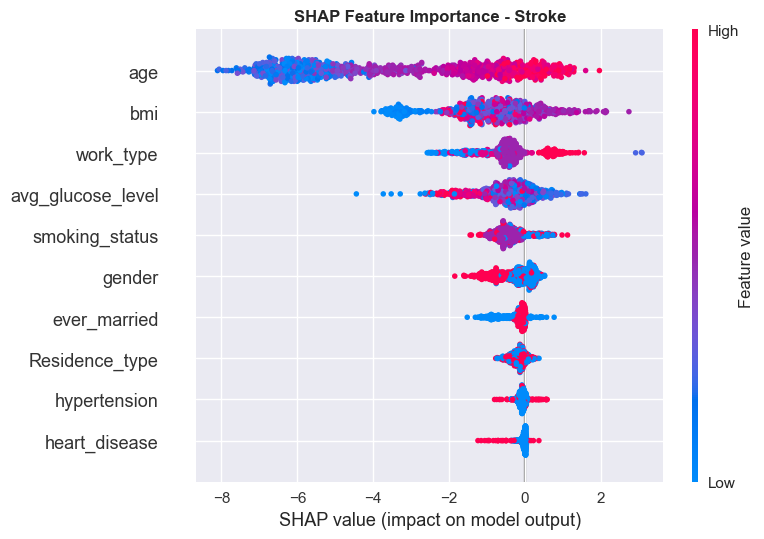

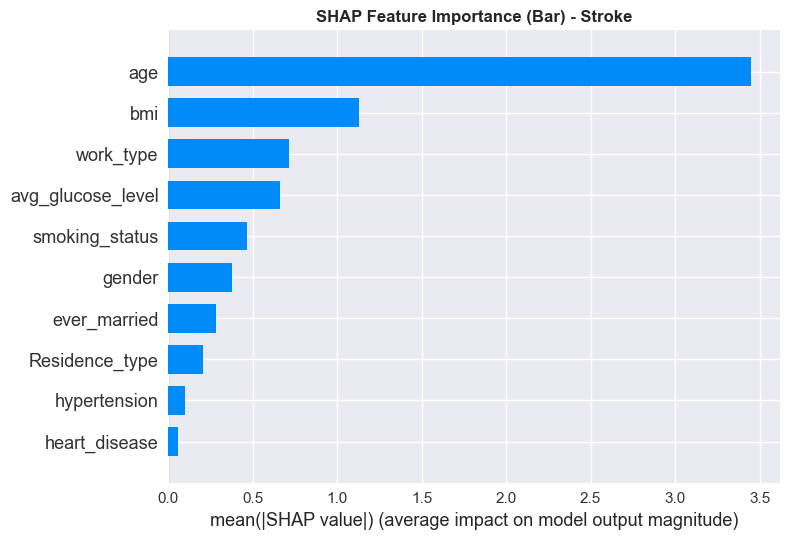

SHAP Analysis Complete!

Top Features by SHAP:
age                  3.448887
bmi                  1.128977
work_type            0.714638
avg_glucose_level    0.662242
smoking_status       0.465062
gender               0.378102
ever_married         0.284330
Residence_type       0.203070
hypertension         0.097556
heart_disease        0.056584
dtype: float32


In [10]:
# Step 7: SHAP Explainability

print("=" * 50)
print("STEP 7: SHAP EXPLAINABILITY")
print("=" * 50)

if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.KernelExplainer(
        best_model.predict_proba,
        shap.sample(X_train, 100))

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

if len(shap_vals.shape) > 2:
    shap_vals = shap_vals[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance - Stroke',
          fontweight='bold')
plt.tight_layout()
plt.savefig('E:/HealthGuard_AI/reports/stroke_shap.png',
            dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar) - Stroke',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("SHAP Analysis Complete!")

# Fix length mismatch
shap_mean = np.abs(shap_vals).mean(axis=0).flatten()

# Take only first n values matching columns
n_features = len(X_train.columns)
shap_mean = shap_mean[:n_features]

shap_importance = pd.Series(
    shap_mean,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop Features by SHAP:")
print(shap_importance)

In [11]:
# Step 8: Save Model

model_path = "E:/HealthGuard_AI/models/saved/stroke_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:5])
print(f"Model: {best_model_name}")
print(f"Saved at: {model_path}")
print(f"Verification: {test_pred}")
print("Model Saved and Verified!")

Model: XGBoost
Saved at: E:/HealthGuard_AI/models/saved/stroke_model.pkl
Verification: [0 0 0 0 0]
Model Saved and Verified!


In [12]:
# Final Summary

print("=" * 60)
print("   STROKE MODEL TRAINING - FINAL SUMMARY")
print("=" * 60)

print("\nCROSS VALIDATION RESULTS:")
print("-" * 40)
for name, cv in cv_results.items():
    print(f"{name}: {cv['Mean F1']:.4f} (+/- {cv['Std F1']:.4f})")

print("\nFINAL MODEL PERFORMANCE:")
print("-" * 40)
print(results_df.to_string())

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

print(f"\nModel saved: stroke_model.pkl")
print("\nStroke Model Training Complete! ")
print("=" * 60)

   STROKE MODEL TRAINING - FINAL SUMMARY

CROSS VALIDATION RESULTS:
----------------------------------------
Logistic Regression: 0.7989 (+/- 0.0089)
Random Forest: 0.9671 (+/- 0.0038)
XGBoost: 0.9665 (+/- 0.0050)
SVM: 0.8767 (+/- 0.0037)
Neural Network: 0.9639 (+/- 0.0069)

FINAL MODEL PERFORMANCE:
----------------------------------------
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.7480     0.1116  0.8182    0.1964   0.8639
Random Forest          0.9327     0.0938  0.0909    0.0923   0.8204
XGBoost                0.9555     0.3333  0.1818    0.2353   0.8267
SVM                    0.8062     0.1215  0.6667    0.2056   0.8142
Neural Network         0.9236     0.1136  0.1515    0.1299   0.7722

BEST MODEL: XGBoost
Accuracy:  0.9555
Precision: 0.3333
Recall:    0.1818
F1 Score:  0.2353
AUC ROC:   0.8267

Model saved: stroke_model.pkl

Stroke Model Training Complete! 
